In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import os
os.chdir("/home/zongchen/stationary_mmd_slides")
import matplotlib.cm as cm
import matplotlib

import sys
sys.path.append("/home/zongchen/mmd_flow_cubature")
from mmd_flow.kernels import gaussian_kernel
jax.config.update("jax_enable_x64", True)
# Flow cells select their backend explicitly.

from tqdm import tqdm

plt.rcParams['axes.grid'] = True
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.labelsize'] = 18
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath, amsfonts}')

# plt.rc('font', family='Arial', size=12)
plt.rc('axes', titlesize=16, labelsize=18, grid=True)
plt.rc('lines', linewidth=2)
plt.rc('legend', fontsize=18, frameon=False)
plt.rc('xtick', labelsize=14, direction='in')
plt.rc('ytick', labelsize=14, direction='in')
plt.rc('figure', figsize=(6, 4), dpi=100)


In [3]:
trajectory = jnp.load("/home/zongchen/mini_mmd/Ys.npy")

from mmd_flow.distributions import Cross
from mmd_flow.kernels import gaussian_kernel

k = 2
w = 0.2
h = 1.0
skip = 1.5
kernel = gaussian_kernel(0.5)
distribution = Cross(kernel=kernel, w=w, h=h, k=k, skip=skip)

rng_key = jax.random.PRNGKey(1)
iid_samples = distribution.sample(20, rng_key)

resolution = 100
h_prime = 0.75
x_lower, x_upper = -h_prime - skip * (k-1), h_prime
y_lower, y_upper = -h_prime, h_prime + skip * (k-1)
x = np.linspace(x_lower, x_upper, resolution)
y = np.linspace(y_lower, y_upper, resolution)
X, Y = np.meshgrid(x, y)

pdf = distribution.pdf(jnp.array([X.flatten(), Y.flatten()]).T)
pdf = pdf.reshape(X.shape)


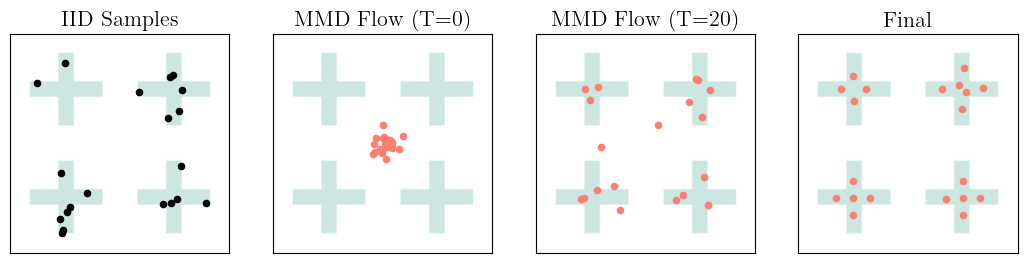

In [7]:
import matplotlib.colors as mcolors
# 204, 230, 225
custom_color = (204/255, 230/255, 225/255)
cmap = mcolors.ListedColormap([custom_color])
cmap.set_bad('white')  # NaN will be white

fig, axs = plt.subplots(1, 4, figsize=(13, 4))
for i in range(4):
    axs[i].imshow(pdf, extent=(x_lower, x_upper, y_lower, y_upper), vmin=0, vmax=1, cmap=cmap)
    axs[i].grid(False)               # Turn off grid
    axs[i].set_xticks([])           # Remove x ticks
    axs[i].set_yticks([])           # Remove y ticks
    axs[i].set_xlabel('')           # Remove x-axis label
    axs[i].set_ylabel('')           # Remove y-axis label

axs[0].scatter(iid_samples[:, 0], iid_samples[:, 1], s=20, c='black', alpha=1.0)
axs[0].set_title("IID Samples")

N = 20
d = 2
Y = jax.random.normal(rng_key, shape=(N, d)) / 10. + jnp.array([[-0.75, 0.75]])
axs[1].scatter(Y[:, 0], Y[:, 1], s=20, c='salmon', alpha=1.0)
axs[1].set_title("MMD Flow (T=0)")

axs[2].scatter(trajectory[2, :, 0], trajectory[2, :, 1], s=20, c='salmon', alpha=1.0)
axs[2].set_title("MMD Flow (T=20)")

axs[3].scatter(trajectory[-1, :, 0], trajectory[-1, :, 1], s=20, c='salmon', alpha=1.0)
axs[3].set_title("Final")
save_path = "/home/zongchen/stationary_mmd_slides/figures/illustration_stationary.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, bbox_inches='tight')
plt.show()


/home/zongchen/miniconda3/envs/thin_mfld/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Gaussian MMD flow: 100%|██████████| 10000/10000 [00:01<00:00, 9785.21step/s]


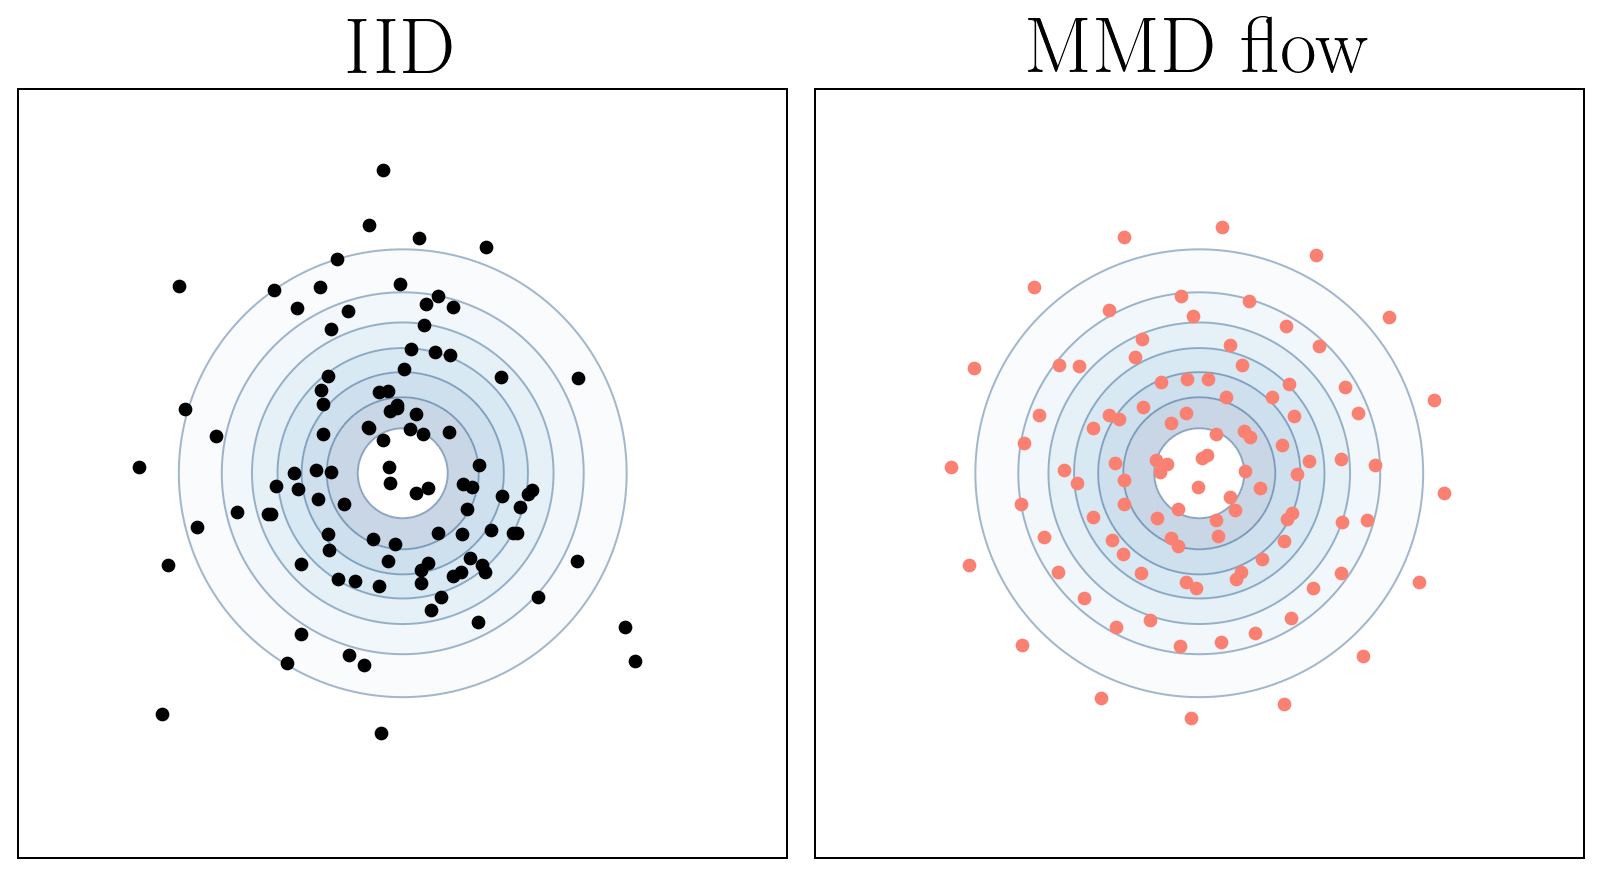

In [5]:
# Two-panel summary: Gaussian IID and Gaussian MMD flow only.
# The Gaussian MMD flow uses a Gaussian kernel and runs on GPU.

from tqdm.auto import tqdm

try:
    summary_gpu_devices = jax.devices("gpu")
except RuntimeError as err:
    raise RuntimeError(
        "No JAX GPU device is visible for the Gaussian MMD flow. Check that "
        "/dev/nvidia* exists, nvidia-smi works, and the NVIDIA driver is running."
    ) from err

if not summary_gpu_devices:
    raise RuntimeError(
        "No JAX GPU device is visible for the Gaussian MMD flow. Check that "
        "/dev/nvidia* exists, nvidia-smi works, and CUDA is visible to JAX."
    )

gaussian_n = 100
gaussian_dim = 2
gaussian_sigma = 0.45
gaussian_steps = 10000
gaussian_step_size = 6.0
gaussian_plot_limit = 3.5

key_init, key_iid = jax.random.split(jax.random.PRNGKey(10))
with jax.default_device(summary_gpu_devices[0]):
    gaussian_particles = 0.35 * jax.random.normal(
        key_init, (gaussian_n, gaussian_dim), dtype=jnp.float64
    )
    gaussian_iid_samples = jax.random.normal(
        key_iid, (gaussian_n, gaussian_dim), dtype=jnp.float64
    )


def summary_gaussian_kernel_mean_to_standard_normal(x, bandwidth):
    scale = (bandwidth**2 / (bandwidth**2 + 1.0)) ** (gaussian_dim / 2)
    return scale * jnp.exp(-0.5 * jnp.sum(x**2, axis=-1) / (bandwidth**2 + 1.0))


@jax.jit
def summary_population_mmd2_gradient(x):
    n = x.shape[0]
    diff = x[:, None, :] - x[None, :, :]
    k_xx = jnp.exp(-0.5 * jnp.sum(diff**2, axis=-1) / gaussian_sigma**2)
    repulsion_grad = -(2.0 / (n**2 * gaussian_sigma**2)) * jnp.sum(k_xx[:, :, None] * diff, axis=1)
    mean_embed = summary_gaussian_kernel_mean_to_standard_normal(x, gaussian_sigma)
    attraction_grad = (2.0 / n) * (x / (gaussian_sigma**2 + 1.0)) * mean_embed[:, None]
    return repulsion_grad + attraction_grad


@jax.jit
def summary_gaussian_flow_step(x):
    return x - gaussian_step_size * summary_population_mmd2_gradient(x)


progress = tqdm(range(gaussian_steps), desc="Gaussian MMD flow", unit="step")
for step in progress:
    gaussian_particles = summary_gaussian_flow_step(gaussian_particles)
    if (step + 1) % 50 == 0:
        gaussian_particles.block_until_ready()
gaussian_particles.block_until_ready()

gaussian_iid_samples, gaussian_particles = jax.device_get(
    (gaussian_iid_samples, gaussian_particles)
)

grid_resolution = 220
grid_axis = np.linspace(-gaussian_plot_limit, gaussian_plot_limit, grid_resolution)
grid_x, grid_y = np.meshgrid(grid_axis, grid_axis)
gaussian_pdf = (1.0 / (2.0 * np.pi)) * np.exp(-0.5 * (grid_x**2 + grid_y**2))
gaussian_levels = np.linspace(0.02, gaussian_pdf.max() * 0.92, 7)

fig, axs = plt.subplots(1, 2, figsize=(9, 5), dpi=180)

for ax, pts, title, color in [
    (axs[0], gaussian_iid_samples, "IID", "black"),
    (axs[1], gaussian_particles, "MMD flow", "salmon"),
]:
    pts = np.asarray(pts)
    ax.contourf(grid_x, grid_y, gaussian_pdf, levels=gaussian_levels, cmap="Blues", alpha=0.22, zorder=0)
    ax.contour(grid_x, grid_y, gaussian_pdf, levels=gaussian_levels, colors="#5b7fa4", linewidths=0.8, alpha=0.55, zorder=1)
    ax.scatter(pts[:, 0], pts[:, 1], s=20, c=color, alpha=1.0, zorder=2)
    ax.set_xlim(-gaussian_plot_limit, gaussian_plot_limit)
    ax.set_ylim(-gaussian_plot_limit, gaussian_plot_limit)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=32)
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.tight_layout()
summary_save_path = "/home/zongchen/stationary_mmd_slides/figures/sampling_gaussian_two_panel_summary.pdf"
os.makedirs(os.path.dirname(summary_save_path), exist_ok=True)
fig.savefig(summary_save_path, bbox_inches="tight")
plt.show()


Gaussian MMD trajectory:  11%|█         | 1083/10000 [00:00<00:00, 10732.62step/s]

Gaussian MMD trajectory: 100%|██████████| 10000/10000 [00:00<00:00, 10799.34step/s]


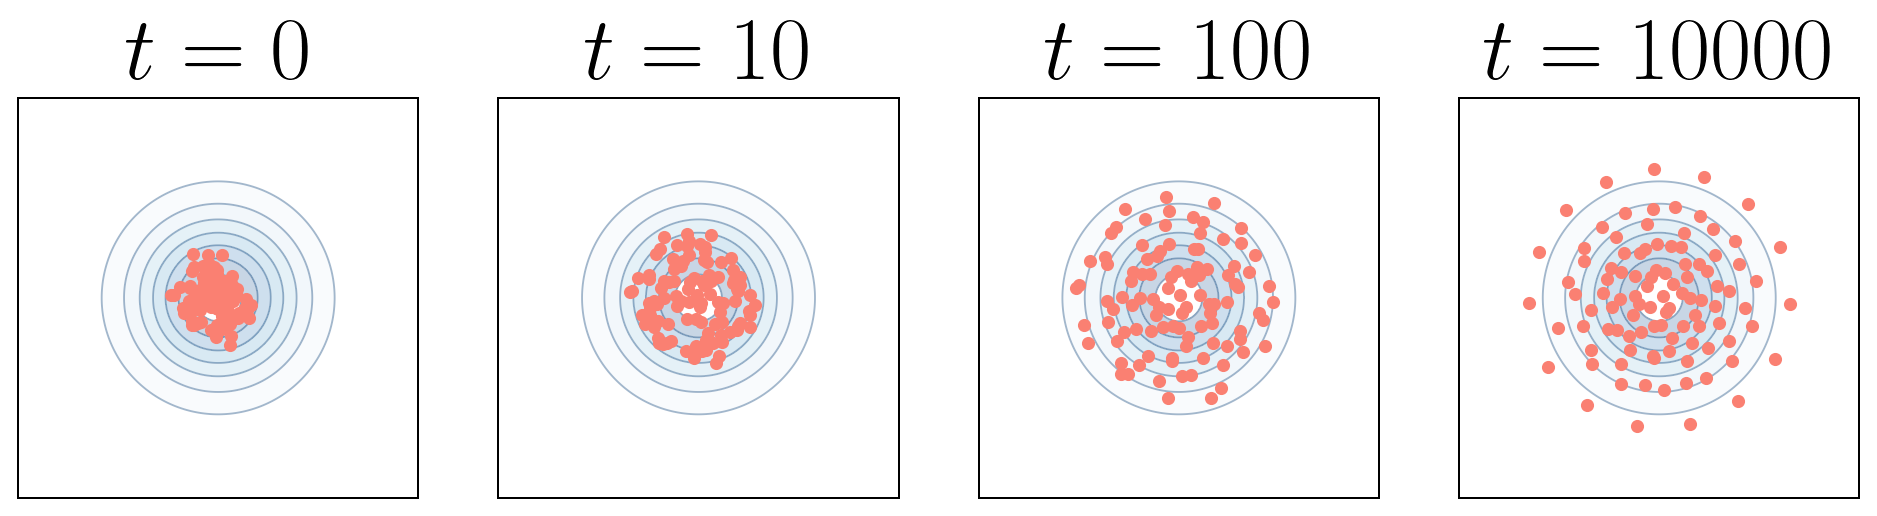

In [6]:
# Four-snapshot trajectory of the Gaussian MMD flow.
# Reuses the same target, kernel bandwidth, initialization, and step size as the two-panel summary above.

from tqdm.auto import tqdm

try:
    trajectory_devices = jax.devices("gpu")
except RuntimeError:
    trajectory_devices = []
if not trajectory_devices:
    trajectory_devices = [jax.devices("cpu")[0]]

if "gaussian_n" not in globals():
    gaussian_n = 100
    gaussian_dim = 2
    gaussian_sigma = 0.45
    gaussian_steps = 10000
    gaussian_step_size = 6.0
    gaussian_plot_limit = 3.5

if "summary_gaussian_kernel_mean_to_standard_normal" not in globals():
    def summary_gaussian_kernel_mean_to_standard_normal(x, bandwidth):
        scale = (bandwidth**2 / (bandwidth**2 + 1.0)) ** (gaussian_dim / 2)
        return scale * jnp.exp(-0.5 * jnp.sum(x**2, axis=-1) / (bandwidth**2 + 1.0))

if "summary_population_mmd2_gradient" not in globals():
    @jax.jit
    def summary_population_mmd2_gradient(x):
        n = x.shape[0]
        diff = x[:, None, :] - x[None, :, :]
        k_xx = jnp.exp(-0.5 * jnp.sum(diff**2, axis=-1) / gaussian_sigma**2)
        repulsion_grad = -(2.0 / (n**2 * gaussian_sigma**2)) * jnp.sum(k_xx[:, :, None] * diff, axis=1)
        mean_embed = summary_gaussian_kernel_mean_to_standard_normal(x, gaussian_sigma)
        attraction_grad = (2.0 / n) * (x / (gaussian_sigma**2 + 1.0)) * mean_embed[:, None]
        return repulsion_grad + attraction_grad

if "summary_gaussian_flow_step" not in globals():
    @jax.jit
    def summary_gaussian_flow_step(x):
        return x - gaussian_step_size * summary_population_mmd2_gradient(x)

if "grid_x" not in globals():
    grid_resolution = 220
    grid_axis = np.linspace(-gaussian_plot_limit, gaussian_plot_limit, grid_resolution)
    grid_x, grid_y = np.meshgrid(grid_axis, grid_axis)
    gaussian_pdf = (1.0 / (2.0 * np.pi)) * np.exp(-0.5 * (grid_x**2 + grid_y**2))
    gaussian_levels = np.linspace(0.02, gaussian_pdf.max() * 0.92, 7)

trajectory_snapshot_steps = [0, 10, 100, gaussian_steps]
trajectory_particles = {}

key_traj = jax.random.PRNGKey(10)
with jax.default_device(trajectory_devices[0]):
    x_traj = 0.35 * jax.random.normal(
        key_traj, (gaussian_n, gaussian_dim), dtype=jnp.float64
    )

trajectory_particles[0] = jax.device_get(x_traj)
trajectory_targets = set(trajectory_snapshot_steps[1:])

progress = tqdm(range(1, gaussian_steps + 1), desc="Gaussian MMD trajectory", unit="step")
for step in progress:
    x_traj = summary_gaussian_flow_step(x_traj)
    if step in trajectory_targets:
        x_traj.block_until_ready()
        trajectory_particles[step] = jax.device_get(x_traj)
    elif step % 50 == 0:
        x_traj.block_until_ready()

fig, axs = plt.subplots(1, 4, figsize=(13.2, 3.7), dpi=180)

for ax, step in zip(axs, trajectory_snapshot_steps):
    pts = np.asarray(trajectory_particles[step])
    ax.contourf(grid_x, grid_y, gaussian_pdf, levels=gaussian_levels, cmap="Blues", alpha=0.22, zorder=0)
    ax.contour(grid_x, grid_y, gaussian_pdf, levels=gaussian_levels, colors="#5b7fa4", linewidths=0.75, alpha=0.55, zorder=1)
    ax.scatter(pts[:, 0], pts[:, 1], s=18, c="salmon", alpha=1.0, zorder=2)
    ax.set_xlim(-gaussian_plot_limit, gaussian_plot_limit)
    ax.set_ylim(-gaussian_plot_limit, gaussian_plot_limit)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(rf"$t={step}$", fontsize=36)
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

# fig.tight_layout(w_pad=0.35)
trajectory_save_path = "/home/zongchen/stationary_mmd_slides/figures/sampling_gaussian_mmd_flow_trajectory.pdf"
os.makedirs(os.path.dirname(trajectory_save_path), exist_ok=True)
fig.savefig(trajectory_save_path, bbox_inches="tight")
plt.show()
